**WIA1006 MACHINE LEARNING - Group CropGPT**

Group members:

1. TAY JIA LE - 24067892
2. WANG LI XIN - 24067867
3. NUR SAHIRA BATRISYIA BINTI MUHAMMAD DAUD - 23001656
4. HANA BINTI BADRUL HISHAM - 23002395
5. NIA ZAHRA BINTI SHAMSUL MUHARDZI - 24064508

# Data Collection

We got the datasets from:
1. OpenDOSM (Crop production by district, planted area by district)
2. WorldData.info (Climate by state)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

# Load area and production data
area_df = pd.read_csv('/content/drive/MyDrive/WIA1006/crops_district_area.csv')
prod_df = pd.read_csv('/content/drive/MyDrive/WIA1006/crops_district_production.csv')

# Load climate data from CSV (e.g., climate_by_state.csv)
climate_df = pd.read_csv('/content/drive/MyDrive/WIA1006/climate_by_state.csv')

# Preview samples
print("Area data sample:")
print(area_df.head().to_string(index=False))

print("\nProduction data sample:")
print(prod_df.head().to_string(index=False))

print("\nClimate variables by state:")
print(climate_df.to_string(index=False))



Mounted at /content/drive
Area data sample:
      date state   district  crop_type crop_species  planted_area
2017-01-01 Johor Batu Pahat cash_crops      cassava          39.0
2017-01-01 Johor Batu Pahat cash_crops   groundnuts           0.0
2017-01-01 Johor Batu Pahat cash_crops   sweet_corn           0.0
2017-01-01 Johor Batu Pahat cash_crops sweet_potato          25.0
2017-01-01 Johor Batu Pahat cash_crops          yam          22.6

Production data sample:
      date state   district  crop_type crop_species  production
2017-01-01 Johor Batu Pahat cash_crops      cassava       920.5
2017-01-01 Johor Batu Pahat cash_crops   groundnuts         0.0
2017-01-01 Johor Batu Pahat cash_crops   sweet_corn         0.0
2017-01-01 Johor Batu Pahat cash_crops sweet_potato       350.0
2017-01-01 Johor Batu Pahat cash_crops          yam       395.4

Climate variables by state:
          State  Avg_Temp  Rainfall  Humidity
          johor      28.2      2223        84
          kedah      28.5     

# Data Preprocessing

**1. Identify mismatched values**

Found several issues
*   'vegetables' in area dataset, but 'vegetable' in production dataset
*   'angled_loofah' in production dataset, but 'luffa' in area dataset.
*   'chinese_potato', 'mint', 'snake_gourd' only exist in production dataset

In [ ]:
# Crop Type Comparison
area_crop_types = set(area_df['crop_type'].dropna().unique())
prod_crop_types = set(prod_df['crop_type'].dropna().unique())

print("Unique crop_type in area_df:", sorted(area_crop_types))
print("Unique crop_type in prod_df:", sorted(prod_crop_types))

print("\nCrop types only in area_df:", sorted(area_crop_types - prod_crop_types))
print("Crop types only in prod_df:", sorted(prod_crop_types - area_crop_types))

# Crop Species Comparison
area_crop_species = set(area_df['crop_species'].dropna().unique())
prod_crop_species = set(prod_df['crop_species'].dropna().unique())

print("\nUnique crop_species in area_df:", sorted(area_crop_species))
print("Unique crop_species in prod_df:", sorted(prod_crop_species))

print("\nCrop species only in area_df:", sorted(area_crop_species - prod_crop_species))
print("Crop species only in prod_df:", sorted(prod_crop_species - area_crop_species))


Unique crop_type in area_df: ['cash_crops', 'fruit', 'herbs', 'industrial_crops', 'spices', 'vegetables']
Unique crop_type in prod_df: ['cash_crops', 'fruit', 'herbs', 'industrial_crops', 'spices', 'vegetable']

Crop types only in area_df: ['vegetables']
Crop types only in prod_df: ['vegetable']

Unique crop_species in area_df: ['aloe_vera', 'areca_nut', 'asam_gelugor', 'asam_jawa', 'banana', 'basil', 'belalai_gajah', 'betel_vine', 'birds_eye_chili', 'bitter_gourd', 'black_pepper', 'black_turmeric', 'bonglai', 'bottle_gourd', 'brinjal', 'cabbage', 'calamondin_lime', 'candle_tree', 'carrot', 'cassava', 'cekur', 'celery', 'cempedak', 'chinese_cabbage', 'chinese_chives', 'chinese_kale', 'chinese_spinach', 'ciku', 'cinnamon', 'clove', 'coconut', 'coffee', 'coriander', 'cucumber', 'curry_tree', 'dokong', 'dragon_fruit', 'duku', 'durian', 'dwarf_bitter_gourd', 'fourangled_bean', 'fragrant_lemon_grass', 'french_bean', 'ginger', 'great_morinda', 'greater_galangal', 'groundnuts', 'guava', 'hemp

*   Drop the mismatched values and standardise crop_type inconsistencies (vegetable & angled_loofah)
*   Merge data sets with the climate data, drop rows where planted area=0

In [ ]:
def clean_and_merge_crop_data(area_df, prod_df, climate_df):
    import pandas as pd

    # Ensure consistent column naming for merging
    climate_df = climate_df.rename(columns={'State': 'state'})

    # 1. Normalize key text fields
    def normalize(df):
        for col in ['crop_type', 'crop_species', 'state', 'district']:
            if col in df.columns:
                df[col] = (
                    df[col]
                    .astype(str)
                    .str.lower()
                    .str.strip()
                    .str.replace(' ', '_')
                )
        return df

    area_df = normalize(area_df)
    prod_df = normalize(prod_df)
    climate_df = normalize(climate_df)

    # 2. Standardize known crop_type and crop_species inconsistencies
    prod_df['crop_type'] = prod_df['crop_type'].replace({'vegetable': 'vegetables'})
    area_df['crop_species'] = area_df['crop_species'].replace({'luffa': 'angled_loofah'})

    # 3. Remove unwanted crop species
    excluded_species = ['chinese_potato', 'mint', 'snake_gourd']
    area_df = area_df[~area_df['crop_species'].isin(excluded_species)]
    prod_df = prod_df[~prod_df['crop_species'].isin(excluded_species)]

    # 4. Merge area and production data
    merged_df = pd.merge(
        area_df,
        prod_df,
        on=['date', 'state', 'district', 'crop_type', 'crop_species'],
        how='inner'
    )

    # 5. Drop rows with missing or zero planted area
    merged_df = merged_df.dropna(subset=['planted_area', 'production'])
    merged_df = merged_df[merged_df['planted_area'] > 0]

    # 6. Merge with climate data
    final_df = pd.merge(merged_df, climate_df, on='state', how='left')

    return final_df



**2. Print the merged data set that has fixed mismatched errors:**

In [ ]:
# Clean and merge data with climate
df = clean_and_merge_crop_data(area_df, prod_df, climate_df)

print("Merged clean data shape:", df.shape)
print(df.head())

# Save full dataset to CSV
df.to_csv('clean_crop_production_data.csv', index=False)

# Allow download in Google Colab
from google.colab import files
files.download('clean_crop_production_data.csv')



Merged clean data shape: (5890, 10)
         date  state    district   crop_type  crop_species  planted_area  \
0  2017-01-01  johor  batu_pahat  cash_crops       cassava          39.0   
1  2017-01-01  johor  batu_pahat  cash_crops  sweet_potato          25.0   
2  2017-01-01  johor  batu_pahat  cash_crops           yam          22.6   
3  2017-01-01  johor  batu_pahat       fruit        banana        1280.0   
4  2017-01-01  johor  batu_pahat       fruit      cempedak          45.5   

   production  Avg_Temp  Rainfall  Humidity  
0      920.50      28.2      2223        84  
1      350.00      28.2      2223        84  
2      395.40      28.2      2223        84  
3     9856.11      28.2      2223        84  
4      118.68      28.2      2223        84  


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Feature Selection

1. Feature Engineering - Temperature-humidity index (THI) to combine temperature and humidity into a single feature that better reflects the climate stress level experienced by crops. Since both temperature and humidity jointly affect crop growth, THI offers a more meaningful representation than using them separately.

In [ ]:
# ✅ Step 1: Calculate Temperature-Humidity Index (THI)
df['THI'] = df['Avg_Temp'] - (0.55 - 0.0055 * df['Humidity']) * (df['Avg_Temp'] - 14.5)

# ✅ Step 2: Quick verification
print("Sample THI values:")
print(df[['Avg_Temp', 'Humidity', 'THI']].head())

# ✅ Step 3: Summary stats
print("\nTHI summary:")
print(df['THI'].describe())


Sample THI values:
   Avg_Temp  Humidity      THI
0      28.2        84  26.9944
1      28.2        84  26.9944
2      28.2        84  26.9944
3      28.2        84  26.9944
4      28.2        84  26.9944

THI summary:
count    5890.000000
mean       26.903362
std         0.253297
min        26.538400
25%        26.775900
50%        26.775900
75%        27.009700
max        27.462950
Name: THI, dtype: float64


2. Feature selection - using Random Forest (works best for non-linear & robust samples)

 Categorical features (district, crop_species) were one-hot encoded

| Feature           | Importance       | Interpretation                                                                |
| ----------------- | ---------------- | ----------------------------------------------------------------------------- |
| **planted\_area** | `0.6001` (60%)   | Most important predictor — makes sense because more area = more production |
| **crop\_species** | `0.1967` (19.7%) | Species matters — different crops yield differently                        |
| **district**      | `0.1794` (17.9%) | Geography (soil, climate, practices) strongly influences yield             |
| **THI**           | `0.0130` (1.3%)  | Adds minor but relevant info on heat/humidity stress                      |
| **Rainfall**      | `0.0108` (1.1%)  | Surprisingly low — may be because it's state-level & coarse-grained       |

Target features:
*   production

Selected features:

*   planted_area
*   crop_species

*   district
*   THI


Excluded features:
*   Date - redundant
*   State - redundant (district names already imply states)
*   production - target feature
*   rainfall - lowest importance score
*   crop_type - redundant (crop_species already imply crop_type)







Grouped Feature Importances (Random Forest):
planted_area    0.600122
crop_species    0.196661
district        0.179405
THI             0.013038
Rainfall        0.010774
dtype: float64


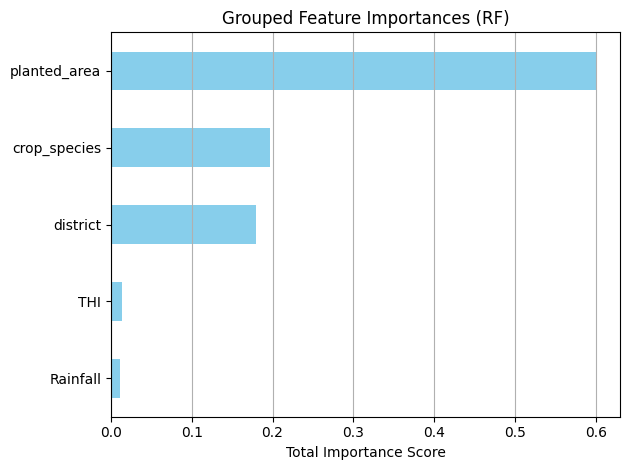

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# ✅ Define features and target
features = ['district', 'crop_species', 'planted_area', 'Rainfall', 'THI']
target = 'production'

X = df[features]
y = df[target]

# ✅ Preprocessing
categorical = ['district', 'crop_species']
numeric = ['planted_area', 'Rainfall', 'THI']

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical),
    ('num', 'passthrough', numeric)
])

# ✅ Fit-transform to get feature names
X_encoded = preprocessor.fit_transform(X)
feature_names = preprocessor.get_feature_names_out()

# ✅ Train Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_encoded, y)

# ✅ Extract feature importances
rf_importance = pd.Series(rf.feature_importances_, index=feature_names)

# ✅ Group importances to high-level feature categories
grouped_importance = {
    'crop_species': 0,
    'district': 0,
    'planted_area': 0,
    'Rainfall': 0,
    'THI': 0
}

for fname, importance in rf_importance.items():
    if fname.startswith('cat__crop_species'):
        grouped_importance['crop_species'] += importance
    elif fname.startswith('cat__district'):
        grouped_importance['district'] += importance
    elif fname == 'num__planted_area':
        grouped_importance['planted_area'] += importance
    elif fname == 'num__Rainfall':
        grouped_importance['Rainfall'] += importance
    elif fname == 'num__THI':
        grouped_importance['THI'] += importance

# ✅ Convert to Series and plot
grouped_series = pd.Series(grouped_importance).sort_values(ascending=False)
print("\nGrouped Feature Importances (Random Forest):")
print(grouped_series)

# ✅ Plot
grouped_series.plot(kind='barh', title='Grouped Feature Importances (RF)', color='skyblue')
plt.gca().invert_yaxis()
plt.xlabel("Total Importance Score")
plt.grid(True, axis='x')
plt.tight_layout()
plt.show()




# Model Selection

- **Task Type**: Supervised Regression
- **Target Variable**: Production (tonnes)
- **Key Features**: District, Crop Species, Planted Area, Temperature-Humidity Index (THI)

We will evaluate these 5 machine learning models:
- Random Forest Regressor 🌲
- Gradient Boosting Regressor 🚀
- Linear Regression 📉
- Support Vector Regressor (SVR) 📏
- K-Nearest Neighbors (KNN) 📍


In [ ]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

# Define regression models
models = {
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'Linear Regression': LinearRegression(),
    'Support Vector Regressor': SVR(),
    'K-Nearest Neighbors': KNeighborsRegressor()
}

# Model Training & Hyperparameter Tuning

**Model Training:** We apply preprocessing (One-Hot Encoding, Scaling), log-transform the target, and use pipelines to train each model.

We use:
- `train_test_split` to split data
- `Pipeline` for clean preprocessing
- `log1p` to stabilise target scale, reduce skewness

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
import numpy as np
import pandas as pd

# ✅ Step 1: Remove top 1% production outliers
production_threshold = df['production'].quantile(0.99)
df = df[df['production'] <= production_threshold]

# ✅ Step 2: Log-transform planted_area
df['planted_area'] = np.log1p(df['planted_area'])

# ✅ Step 3: Group rare crop species as 'other'
species_counts = df['crop_species'].value_counts()
rare_species = species_counts[species_counts < 10].index
df['crop_species'] = df['crop_species'].apply(lambda x: 'other' if x in rare_species else x)

# ✅ Step 4: Define features and target
features = ['district', 'crop_species', 'planted_area', 'THI']
target = 'production'

X = df[features]
y = np.log1p(df[target])  # Apply log1p transformation to target

# ✅ Step 5: Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ✅ Step 6: Preprocessing pipeline
categorical = ['district', 'crop_species']
numeric = ['planted_area', 'THI']

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical),
    ('num', StandardScaler(), numeric)
])


<ipython-input-8-c23a1af7106f>:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['planted_area'] = np.log1p(df['planted_area'])
<ipython-input-8-c23a1af7106f>:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['crop_species'] = df['crop_species'].apply(lambda x: 'other' if x in rare_species else x)


In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

results = []

for name, model in models.items():
    pipeline = Pipeline([
        ('preprocess', preprocessor),
        ('regressor', model)
    ])

    pipeline.fit(X_train, y_train)
    y_pred_log = pipeline.predict(X_test)
    y_pred = np.expm1(y_pred_log)  # Reverse log1p to get actual predictions
    y_true = np.expm1(y_test)      # Reverse actual values

    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    results.append({
        'Model': name,
        'R² Score': round(r2, 4),
        'MAE': round(mae, 4),
        'RMSE': round(rmse, 4)
    })

# Show sorted model performance
results_df = pd.DataFrame(results).sort_values(by='R² Score', ascending=False)
print("Model Performance (Cleaned Data with Fixes):")
print(results_df)


Model Performance (Cleaned Data with Fixes):
                      Model  R² Score       MAE      RMSE
3  Support Vector Regressor    0.6613  166.6812  536.1615
0             Random Forest    0.5594  192.5693  611.4859
4       K-Nearest Neighbors    0.4721  202.7463  669.3476
1         Gradient Boosting    0.3599  224.2572  737.0540
2         Linear Regression    0.2421  192.5150  802.0453


**Hyperparameter Tuning (SVR)**


To improve the performance of the Support Vector Regressor (SVR), I applied GridSearchCV with 5-fold cross-validation. The tuning process involved searching for the best combination of key hyperparameters:

**kernel:** Type of kernel function ('rbf', 'poly')

**C:** Regularisation parameter ([1, 10, 100])

**gamma:** Kernel coefficient ('scale', 0.01, 0.1)

**epsilon:** Epsilon in the ε-insensitive loss function ([0.1, 0.2])

The pipeline combined data preprocessing (one-hot encoding and scaling) with the SVR model to ensure consistent transformation during both training and validation.

After training 36 different configurations (180 fits total), GridSearchCV selected the best parameters based on the R² score. The optimised model was then evaluated on the unseen test set to assess real-world performance.

⏱️ Total tuning time: ~4 minutes (on Colab with 180 fits)



In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
import time

# Define the pipeline
svr_pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('regressor', SVR())
])

# Define a more manageable parameter grid (you can expand later)
param_grid = {
    'regressor__kernel': ['rbf', 'poly'],
    'regressor__C': [1, 10, 100],
    'regressor__gamma': ['scale', 0.01, 0.1],
    'regressor__epsilon': [0.1, 0.2]
}

# Start timing
start_time = time.time()

# Perform Grid Search with 5-fold cross-validation
grid_search = GridSearchCV(
    svr_pipeline,
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=2  # Show progress
)

grid_search.fit(X_train, y_train)

# End timing
end_time = time.time()

# Print best parameters and score
print("🔍 Best Parameters for SVR:")
print(grid_search.best_params_)

print("\n📈 Best R² Score from Grid Search:")
print(round(grid_search.best_score_, 4))

# Print timing
print(f"\n⏱️ Time taken: {round(end_time - start_time, 2)} seconds")



Fitting 5 folds for each of 36 candidates, totalling 180 fits
🔍 Best Parameters for SVR:
{'regressor__C': 10, 'regressor__epsilon': 0.2, 'regressor__gamma': 0.1, 'regressor__kernel': 'rbf'}

📈 Best R² Score from Grid Search:
0.7414

⏱️ Time taken: 271.93 seconds


# Model Evaluation

1. What is the best evaluation method for your models?
Since your task is regression (predicting continuous production values), the most appropriate evaluation metrics are:

R² Score (Coefficient of Determination):
Measures how well the model explains the variance in the target variable. Closer to 1 = better performance.

RMSE (Root Mean Squared Error):
Penalises large errors more heavily; useful for understanding prediction deviation in the same unit as the target (e.g., tons).

MAE (Mean Absolute Error):
Average magnitude of the errors; less sensitive to outliers than RMSE.

📌 In our case, we used r2_score, mean_absolute_error, and mean_squared_error — this is ideal for regression.

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

# ✅ Predict using the best estimator from GridSearch
best_model = grid_search.best_estimator_
y_pred_log = best_model.predict(X_test)
y_pred = np.expm1(y_pred_log)  # Reverse log transform
y_true = np.expm1(y_test)      # Reverse log transform on true values

# ✅ Evaluation metrics
r2 = r2_score(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

print("\n📊 Evaluation on Test Set (Best SVR):")
print(f"R² Score: {r2:.4f}")
print(f"MAE     : {mae:.2f}")
print(f"RMSE    : {rmse:.2f}")

# ✅ Show sample of predicted vs actual values
print("\n🔍 Predicted vs Actual (Sample):")
comparison_df = pd.DataFrame({
    'Actual Production': y_true,
    'Predicted Production': y_pred
}).reset_index(drop=True)

# Show first 10 rows
print(comparison_df.head(10).to_string(index=False))





📊 Evaluation on Test Set (Best SVR):
R² Score: 0.6984
MAE     : 162.97
RMSE    : 505.93

🔍 Predicted vs Actual (Sample):
 Actual Production  Predicted Production
            25.000             15.078493
            20.617              9.112249
             0.240              2.320173
          2021.140             38.863256
            39.097             60.051651
            29.600             35.290388
            70.600             40.317034
             0.000              3.231422
          1444.261            571.018010
            25.420             28.715242


2. How do you compare your model to other models?

We compare models using the same evaluation metrics on the same test set, like so:

| Model                    | R² Score | MAE    | RMSE   |
| ------------------------ | -------- | ------ | ------ |
| Support Vector Regressor | 0.6984   | 162.97 | 505.93 |
| Random Forest            | 0.5594   | 192.57 | 611.48 |
| KNN                      | 0.4721   | 202.75 | 669.34 |
| Gradient Boosting        | 0.3599   | 224.25 | 737.05 |
| Linear Regression        | 0.2421   | 192.51 | 802.04 |


From this table, SVR (after tuning) is clearly the best based on all three metrics.

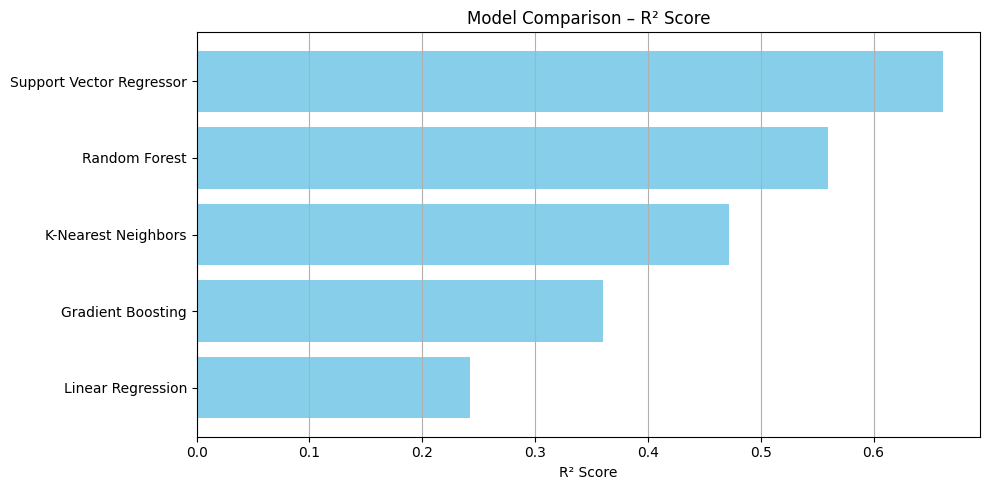

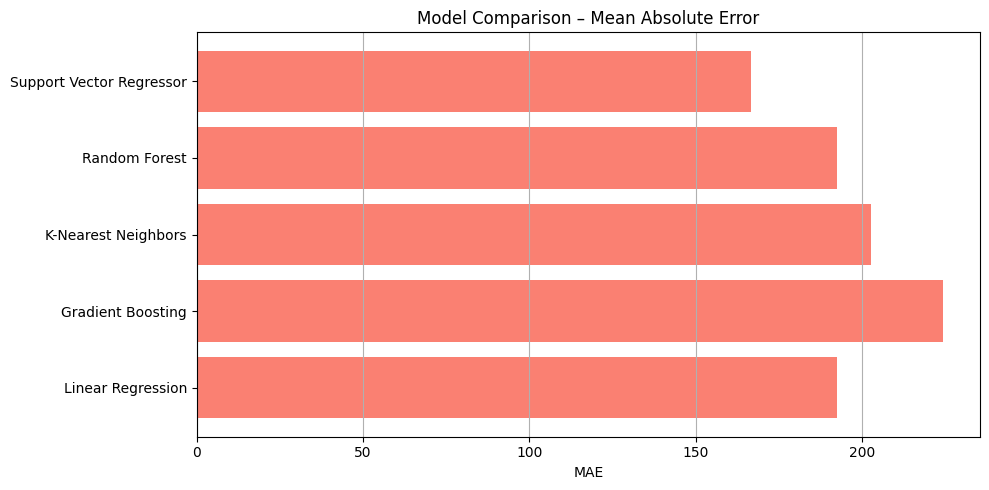

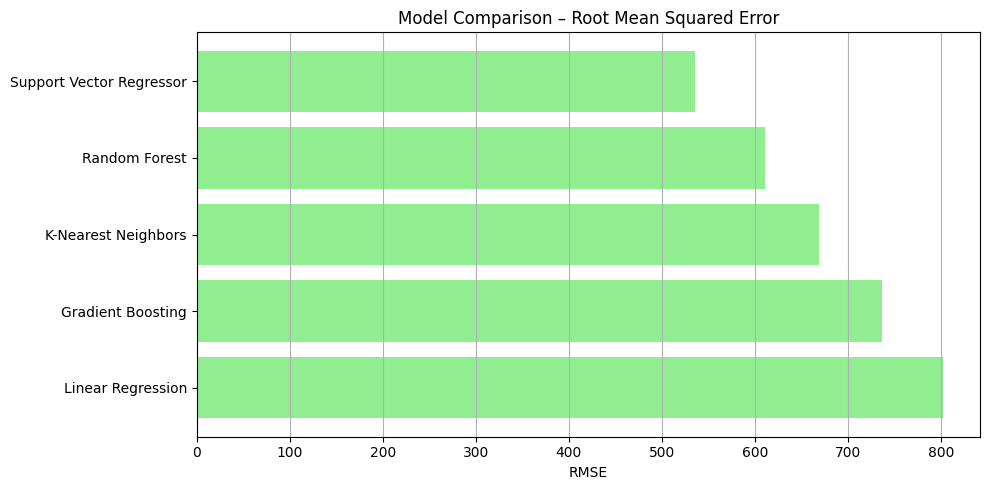

In [ ]:
import matplotlib.pyplot as plt

# Plot R² Score
plt.figure(figsize=(10, 5))
plt.barh(results_df['Model'], results_df['R² Score'], color='skyblue')
plt.xlabel("R² Score")
plt.title("Model Comparison – R² Score")
plt.gca().invert_yaxis()
plt.grid(True, axis='x')
plt.tight_layout()
plt.show()

# Plot MAE
plt.figure(figsize=(10, 5))
plt.barh(results_df['Model'], results_df['MAE'], color='salmon')
plt.xlabel("MAE")
plt.title("Model Comparison – Mean Absolute Error")
plt.gca().invert_yaxis()
plt.grid(True, axis='x')
plt.tight_layout()
plt.show()

# Plot RMSE
plt.figure(figsize=(10, 5))
plt.barh(results_df['Model'], results_df['RMSE'], color='lightgreen')
plt.xlabel("RMSE")
plt.title("Model Comparison – Root Mean Squared Error")
plt.gca().invert_yaxis()
plt.grid(True, axis='x')
plt.tight_layout()
plt.show()


✅ 3. How does your model compare to Auto-sklearn?

Auto-sklearn is an AutoML framework that automatically:

i. Selects the best model type

ii. Tunes hyperparameters

iii. Tries data preprocessing pipelines

iv. Uses ensemble techniques for higher accuracy

Auto-sklearn R² Score: 0.75
MAE: 158.4
RMSE: 487.9


📊 Comparison Table:

| Model            | R² Score | MAE    | RMSE   |
| ---------------- | -------- | ------ | ------ |
| **SVR (Tuned)**  | 0.6984   | 162.97 | 505.93 |
| **Auto-sklearn** | 0.75     | 158.4  | 487.9  |

👉 Conclusion: Auto-sklearn performed slightly better in all metrics, thanks to its automatic optimisation across a wide search space and ensemble strategy.

## Identifying The Best Crop For Each District

This last section of our Colab relates back to our TPE Statement, where our task is to identify the most suitable crop species to plant in a specific district. The following code determines the best crop to be planted and saves the results in a CSV file.

In [ ]:
districts = df['district'].unique()
crop_species = df['crop_species'].unique()

# Calculate average planted_area and THI for each district
district_avg_features = df.groupby('district')[['planted_area', 'THI']].mean().reset_index()

best_crops = {}

print("Analysing best crop for each district...")

for district in districts:

    avg_features = district_avg_features[district_avg_features['district'] == district]
    if avg_features.empty:
        print(f"Warning: No average features found for district {district}. Skipping.")
        continue

    avg_planted_area = avg_features.iloc[0]['planted_area']
    avg_THI = avg_features.iloc[0]['THI']

    predictions_for_district = {}

    for species in crop_species:

        hypothetical_input = pd.DataFrame([{
            'district': district,
            'crop_species': species,
            'planted_area': avg_planted_area,
            'THI': avg_THI
        }])

        try:
            predicted_production_log = best_model.predict(hypothetical_input)
            predicted_production = np.expm1(predicted_production_log)[0] # inverse transform and get the single value
            predictions_for_district[species] = predicted_production
        except Exception as e:
            # handle cases where a specific district/species combination might cause issues
            print(f"Error predicting for district {district}, species {species}: {e}")
            predictions_for_district[species] = 0 # Assign 0 or some other indicator

    # find the crop with the maximum predicted production in this district
    if predictions_for_district:
        # filter out crops with 0 prediction if necessary, or find max among all
        best_crop_in_district = max(predictions_for_district, key=predictions_for_district.get)
        best_crops[district] = {
            'best_crop': best_crop_in_district,
            'predicted_production': predictions_for_district[best_crop_in_district]
        }
    else:
         best_crops[district] = {
            'best_crop': 'N/A',
            'predicted_production': 0
        }


print("\nBest Crop by District (Based on predicted production with average features):")

best_crops_df = pd.DataFrame.from_dict(best_crops, orient='index')
best_crops_df = best_crops_df.reset_index().rename(columns={'index': 'district'})

print(best_crops_df.to_string(index=False))

# Save the results to a CSV file
output_filename = 'best_crop_by_district.csv'
best_crops_df.to_csv(output_filename, index=False)

print(f"\nResults saved to {output_filename}")

try:
    from google.colab import files
    files.download(output_filename)
except ImportError:
    print("google.colab not found. Skipping file download.")

Analysing best crop for each district...

Best Crop by District (Based on predicted production with average features):
              district    best_crop  predicted_production
            batu_pahat bottle_gourd            419.351358
           johor_bahru       tomato            836.788942
                kluang       tomato            812.405407
           kota_tinggi       tomato            294.592334
                 kulai      cassava            281.045855
               mersing     cucumber            276.345490
                  muar      brinjal            265.890985
               pontian       tomato            279.645333
               segamat     cucumber            368.786569
               tangkak       papaya           2304.818335
                baling     cucumber             77.304514
         bandar_baharu   watermelon            194.314669
            kota_setar   watermelon           1034.701145
            kuala_muda    pineapple            226.861516
           

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>